In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
import matplotlib.dates as mdates
import os

from datetime import date
from dateutil.relativedelta import relativedelta

In [2]:
#folder_path = 'C:/Users/Alfredo/Downloads/store-sales-time-series-forecasting/'
folder_path = 'store-sales-time-series-forecasting/'
datasets = {}

for file in os.listdir(folder_path):
    if(file.endswith('.csv')):
        name = os.path.splitext(file)[0]
        file_path = os.path.join(folder_path, file)
        datasets[name] = pd.read_csv(file_path)

In [3]:
for i in datasets.keys():
    print(f'<li>{i}</li>')

<li>holidays_events</li>
<li>oil</li>
<li>sample_submission</li>
<li>stores</li>
<li>test</li>
<li>train</li>
<li>transactions</li>


It looks like we have the following datasets:
<ul>
    <li>holidays_events</li>
    <li>oil</li>
    <li>sample_submission</li>
    <li>stores</li>
    <li>test</li>
    <li>train</li>
    <li>transactions</li>
</ul>

First we inspec the holiday events, it includes 350 holidays with no missing dates. Using the dataset analysis we can see:
<ul>
    <li>there are 6 types of events with holiday being the most observed</li>
    <li>They are mostly distributed between national and local with a few regional</li>
    <li>We have a list of name of the events and cities where this applies. The city might apply</li>
    <li>We have most of them as transferred</li>
</ul>

Next we have the oil prices with missing values. even tho we cant identify the reason for these missing values, we can see the data prior to the missing value and after is not changing too drastically which means we can fill them backwards.

Third we have the sample submission, this can be ignored. 

Fourth we have the stores. This includes 54 stores with no missing values the columns we have are: 
<ul>
    <li>store_nbr</li>
    <li>city</li>
    <li>state</li>
    <li>type</li>
    <li>cluster: the most interesting one, showins us clusters from 1 to 17 with as many as 12 stores per cluster</li>
</ul>

5th we have the test dataset whcih is the dataset we want to forecast for, with the test data in set used for training purposes. both of them have the following columns id, date, store_nbr, family, onpromotion. The only difference here is that the training test set includes the sales column.
The dataset includes information on the categories and the total sales as well as how much as in promotion 

For the test dataset, the sales are betweeen 0 and 125K with the average close to 350 and the 50% around 11. The numbers are floating so is safe to asume the sales are in USD. on the other hand the on promo column includes rounded numbers betweem 0 and 800. I will assume this is the number of items in the section on sale.

The final dataset (transactions) include date, store_nbr and transactions. This looks like is the number of transactions per store per date in the training dataset. We will use this information to create a combined df that we can use for the model.


The plan then is:

<ul>
    <li>Join train with transactions</li>
</ul>


In [4]:
names_datasets = list(datasets.keys())

First we are going to merge the Train dataset with transactions

In [5]:
#import train dataset with all transaction information
df1 = datasets[names_datasets[-2]]
df1['date'] = pd.to_datetime(df1['date'])

In [6]:
df1.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


<ul>
  <li><b>store_nbr:</b> Unique identifier for the store where products are sold.</li>
  <li><b>family:</b> The category or type of product sold (e.g., DAIRY, MEATS).</li>
  <li><b>sales:</b> Total sales for a product family at a specific store on a given date. Note: Fractional values are possible for items sold by weight (eg 1,5 kg of cheese).</li>
  <li><b>onpromotion:</b> Total count of items within a product family that were under promotion at a specific store on a given date.</li>
</ul>

<b>Test Dataset Insights</b>
<table border="1" style="border-collapse: collapse; width: 100%; text-align: left;">
  <thead>
    <tr style="background-color: #f2f2f2;">
      <th style="padding: 8px;">Metric</th>
      <th style="padding: 8px;">Value</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="padding: 8px;">🏬 Total Stores</td>
      <td style="padding: 8px;">54</td>
    </tr>
    <tr>
      <td style="padding: 8px;">📦 Total Categories</td>
      <td style="padding: 8px;">33</td>
    </tr>
    <tr>
      <td style="padding: 8px;">🏆 Top Store</td>
      <td style="padding: 8px;">Store 44 (Bottom: 52)</td>
    </tr>
    <tr>
      <od style="padding: 8px;">🥇 Top Category</td>
      <td style="padding: 8px;">GROCERY I (Bottom: BOOKS)</td>
    </tr>
  </tbody>
</table>

In [7]:
#first we set the multi index for this dataset
df = df1.set_index(['store_nbr', 'family', 'date']).sort_index()

In [8]:
# Returns the subset associated with a specific store and product family from the dataframe df. 
def cross_section(df, store_nbr,family):
    specific_store_data = df.xs(key=(store_nbr, family), level=('store_nbr', 'family'))
    return(specific_store_data)

In [9]:
#plot a dataset based on sales
def my_plot(title, ds, my_color,line_width):
    # Set the style
    sns.set_style("whitegrid")
    
    # Create the plot
    plt.figure(figsize=(7, 5))
    ax = plt.gca()
    sns.lineplot(data=ds, color=my_color, linewidth=line_width, linestyle='-', ax = ax)

    # Customize labels and title
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Sales', fontsize=12)
    plt.title(title, fontsize=14)
    
    # Customize tick labels
    plt.xticks(rotation=45, fontsize=10)  
    plt.yticks(fontsize=10)
    
    # Set the major locator to YearLocator (every 1 year)
    ax.xaxis.set_major_locator(mdates.YearLocator(1))

    # Format the major ticks to display only the year (%Y)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    # Show the plot
    plt.tight_layout()
    plt.show()

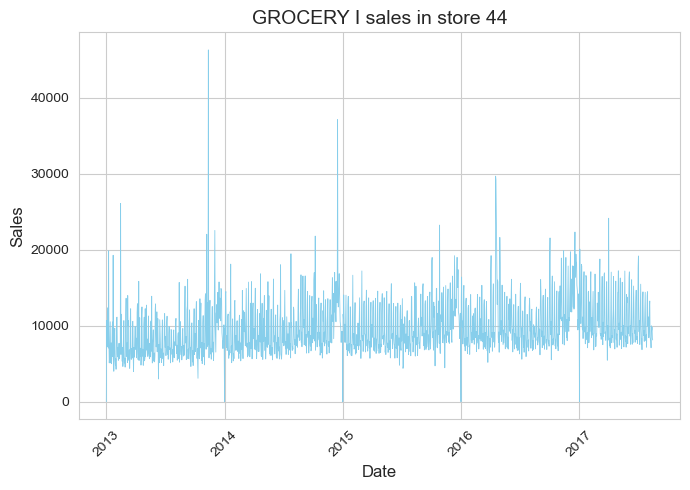

In [10]:
t_df = cross_section(df, 44, 'GROCERY I')
my_plot('GROCERY I sales in store 44', t_df['sales'], 'skyblue',0.6)

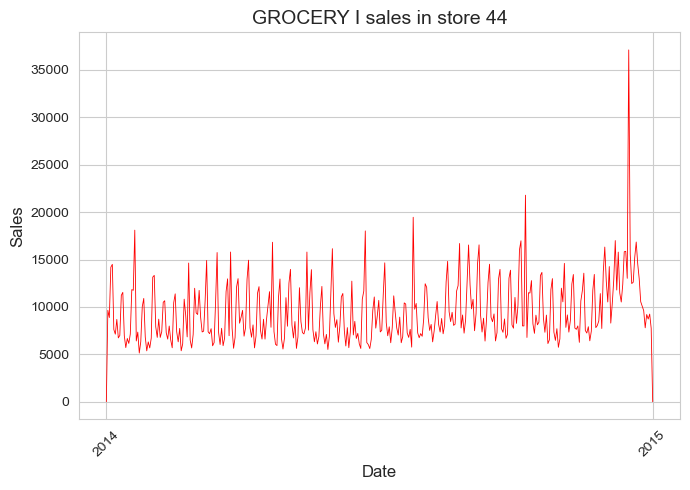

In [11]:
t_df = cross_section(df, 44, 'GROCERY I')
my_plot('GROCERY I sales in store 44', t_df.loc['2014-01-01':'2015-01-01', 'sales'], 'red',0.6)

Based on this, we can see there is a seasonality that repeats through the year and a spike happening near the end of the year (hitting a 0 sales on new years day). Sales also seem to have been growing over the years. Next lets understand the transactions df

In [12]:
#import the number of transactions for the store
df2 = datasets[names_datasets[6]]
df2['date'] = pd.to_datetime(df2['date'])

In [13]:
df2.head()

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358
3,2013-01-02,3,3487
4,2013-01-02,4,1922


In [14]:
len(df2['store_nbr'].unique())

54

In [15]:
#identify missing dates
all_dates = pd.date_range(start=df2.date.min(), end=df2.date.max())
all_dates.difference(df2['date'])

DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-01-01',
               '2016-01-03', '2016-12-25'],
              dtype='datetime64[ns]', freq=None)

In [16]:
all_dates.difference(df1['date'])

DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[ns]', freq=None)

Based on this, it looks like the dates with missing transactions are the christmas days 2013, 2014, 2015 and 2016. It also looks like the Jan missing dates are incorrect. We will join both dfs and fill the missing values with 0

In [17]:
df.head()

id  sales  onpromotion
store_nbr family     date                                
1         AUTOMOTIVE 2013-01-01     0    0.0            0
                     2013-01-02  1782    2.0            0
                     2013-01-03  3564    3.0            0
                     2013-01-04  5346    3.0            0
                     2013-01-05  7128    5.0            0

In [18]:
#merge datasets
df = pd.merge(df, df2.set_index(['store_nbr','date']), left_index = True, right_index = True, how='left')

In [19]:
#fill NA transactions
df['transactions'] = df['transactions'].fillna(0)

In [20]:
idx = pd.IndexSlice
df.loc[idx[:, :, '2013-01-03'], :]

id    sales  onpromotion  \
store_nbr family                     date                                     
1         AUTOMOTIVE                 2013-01-03  3564    3.000            0   
          BABY CARE                  2013-01-03  3565    0.000            0   
          BEAUTY                     2013-01-03  3566    0.000            0   
          BEVERAGES                  2013-01-03  3567  919.000            0   
          BOOKS                      2013-01-03  3568    0.000            0   
...                                               ...      ...          ...   
54        POULTRY                    2013-01-03  5209    4.313            0   
          PREPARED FOODS             2013-01-03  5210    1.000            0   
          PRODUCE                    2013-01-03  5211    0.000            0   
          SCHOOL AND OFFICE SUPPLIES 2013-01-03  5212    0.000            0   
          SEAFOOD                    2013-01-03  5213    2.000            0   

                                                 transactions  
store_nbr family                     date                      
1         AUTOMOTIVE                 2013-01-03        1833.0  
          BABY CARE                  2013-01-03        1833.0  
          BEAUTY                     2013-01-03        1833.0  
          BEVERAGES                  2013-01-03        1833.0  
          BOOKS                      2013-01-03        1833.0  
...                                                       ...  
54        POULTRY                    2013-01-03         920.0  
          PREPARED FOODS             2013-01-03         920.0  
          PRODUCE                    2013-01-03         920.0  
          SCHOOL AND OFFICE SUPPLIES 2013-01-03         920.0  
          SEAFOOD                    2013-01-03         920.0  

[1782 rows x 4 columns]

As we can see, the transactions are repeated for all the same store and dates. now we can continue with the store information.

In [21]:
#import the store information 
df2 = datasets[names_datasets[3]]

In [22]:
df2.head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
1,2,Quito,Pichincha,D,13
2,3,Quito,Pichincha,D,8
3,4,Quito,Pichincha,D,9
4,5,Santo Domingo,Santo Domingo de los Tsachilas,D,4


<Axes: xlabel='type', ylabel='cluster'>

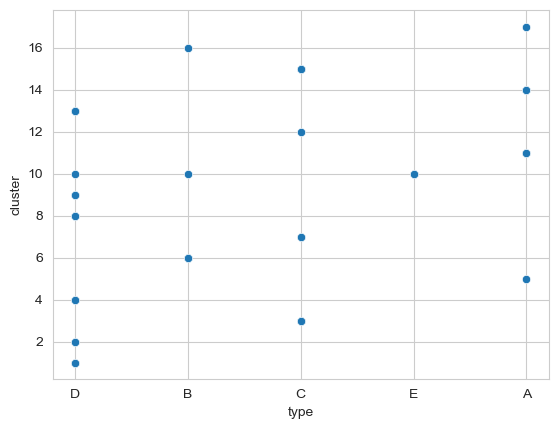

In [23]:
sns.scatterplot(df2, x='type', y='cluster')

<Axes: xlabel='type', ylabel='Count'>

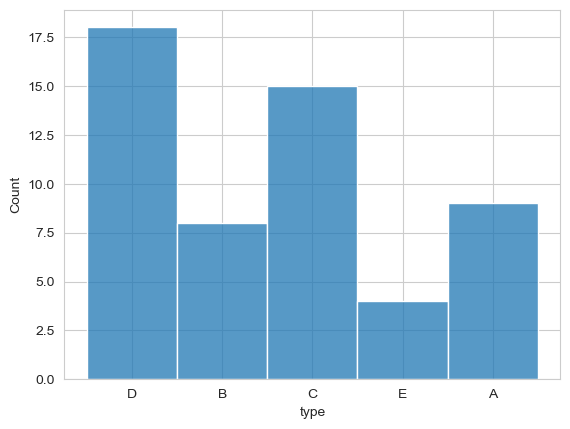

In [24]:
sns.histplot(df2['type'])

<Axes: xlabel='cluster', ylabel='Count'>

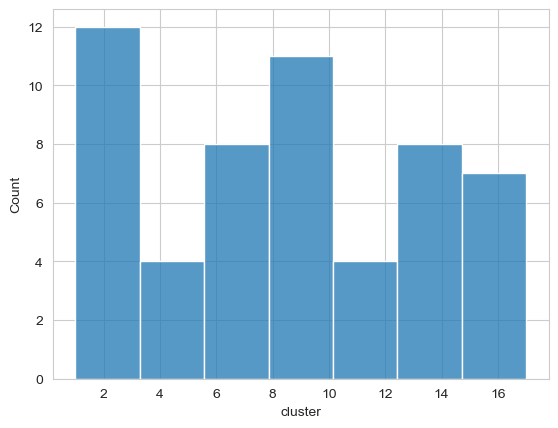

In [25]:
sns.histplot(df2['cluster'])

As we can see, it looks like the store type and cluster are not necessarily related and they both bring important information for the analysis. considering this we will import both

In [26]:
#merge on the index
df = pd.merge(df, df2.set_index(['store_nbr']), left_index = True, right_index = True, how='left')

In [27]:
df.isna().sum()

id              0
sales           0
onpromotion     0
transactions    0
city            0
state           0
type            0
cluster         0
dtype: int64

In [28]:
t_df = df.groupby('store_nbr')[['sales', 'cluster', 'type']].agg({'sales':'sum', 'cluster':'max','type':'max'})

<Axes: xlabel='cluster', ylabel='sales'>

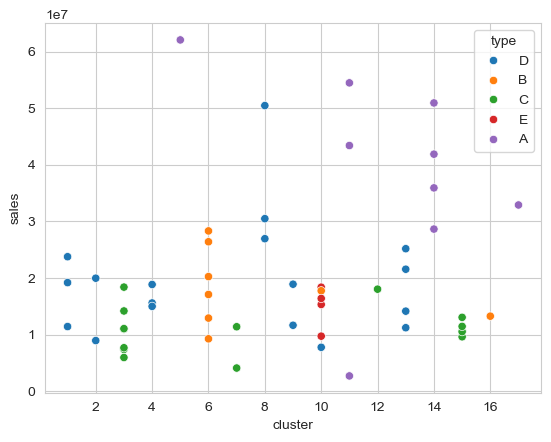

In [29]:
sns.scatterplot(t_df, x='cluster', y='sales', hue='type')

From the previous graph, we can tell taht there is some relationship between the sales, type and clusters. because of this we will keep all of them. Now we can continue with the holiday events:

In [30]:
#import the holiday information 
df2 = datasets[names_datasets[0]]
df2['date'] = pd.to_datetime(df2['date'])

In [31]:
df2[df2['transferred']].head()

,date,type,locale,locale_name,description,transferred
19,2012-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
72,2013-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
135,2014-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
255,2016-05-24,Holiday,National,Ecuador,Batalla de Pichincha,True
266,2016-07-25,Holiday,Local,Guayaquil,Fundacion de Guayaquil,True


In [32]:
df2[(df2['date']>'2014-10-01') & (df2['date']<'2014-10-15')]

,date,type,locale,locale_name,description,transferred
134,2014-10-07,Holiday,Local,Quevedo,Cantonizacion de Quevedo,False
135,2014-10-09,Holiday,National,Ecuador,Independencia de Guayaquil,True
136,2014-10-10,Transfer,National,Ecuador,Traslado Independencia de Guayaquil,False


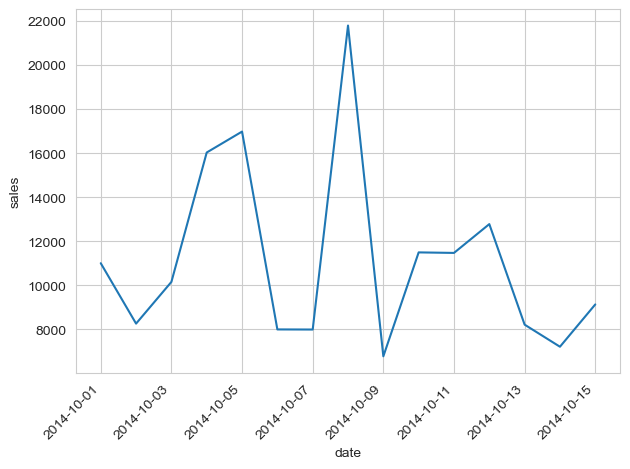

In [33]:
t_df = cross_section(df, 44, 'GROCERY I')
sns.lineplot(t_df.loc['2014-10-01':'2014-10-15','sales'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Based on these prelim results, it looks like the non transferred and transferred dates both add value to the analysis: There is a definite spike the day prior to the holiday with a drop on the holiday date (even tho it was transferred). because of this, we will keep both transferred and non transferred

It looks like the holiday 

In [34]:
cities_df = df.reset_index()['city'].drop_duplicates() #list of cities in the df
cities_main = df2['locale_name'].drop_duplicates()
cities_df[~cities_df.isin(cities_main)] #identify cities not in the 'locale_name' from the dataset

1444872       Daule
1667160    Babahoyo
1889448      Playas
Name: city, dtype: object

In [35]:
cities_main[~cities_main.isin(cities_df)]

1                           Cotopaxi
7                           Imbabura
14                           Ecuador
23    Santo Domingo de los Tsachilas
24                       Santa Elena
Name: locale_name, dtype: object

As it looks like, most of the cities in the transactions are found in the locale_name. We will go ahead with merging in 2 stages:
- by date and locale_name when locale is not National
- by date only if locale is National

In [36]:
df2 = df2.drop(columns='description')
df2_locale = df2[df2['locale']!='National']
df2_nal = df2[df2['locale']=='National']

In [37]:
df2_locale = df2_locale.rename(columns={'locale_name':'city'})

In [38]:
#merge the non national holidays first
df = pd.merge(df.reset_index(), df2_locale, on=['date', 'city'], how='left', suffixes = ('_store', '_holiday'))
#merge the national holidays second
df = pd.merge(df.reset_index(), df2_nal.drop(columns='locale_name'), on=['date'], how='left', suffixes = ('_holiday', '_nal_holiday'))

In [39]:
#rename the column type and reset index
df = df.rename(columns={'type':'type_nal_holiday'})
df = df.set_index(['store_nbr', 'family', 'date']).sort_index()

In [40]:
#fill na with 0 as a way to signify "no holiday"
df = df.fillna(0)

In [41]:
#import the oil information 
df2 = datasets[names_datasets[1]]
df2['date'] = pd.to_datetime(df2['date'])

In [42]:
df2.head()

,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20


In [43]:
df2.isna().sum()

date           0
dcoilwtico    43
dtype: int64

<Axes: xlabel='date', ylabel='dcoilwtico'>

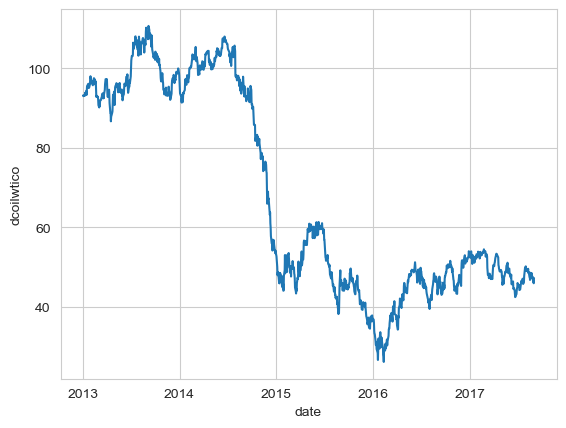

In [44]:
sns.lineplot(df2, x='date', y='dcoilwtico')

In [45]:
all_dates.difference(df2.date).day_name().unique() #identify the missing values

Index(['Saturday', 'Sunday'], dtype='object')

In [46]:
#merge with oil prices
df = pd.merge(df, df2.set_index(['date']), left_index = True, right_index = True, how='left')

In [49]:
df.columns

Index(['index', 'id', 'sales', 'onpromotion', 'transactions', 'city', 'state',
       'type_store', 'cluster', 'type_holiday', 'locale_holiday',
       'transferred_holiday', 'type_nal_holiday', 'locale_nal_holiday',
       'transferred_nal_holiday', 'dcoilwtico'],
      dtype='object')

In [50]:
#fill using last day of the week price and future price for the first day
df['dcoilwtico'] = df.iloc[:,-1].ffill().bfill()

In [55]:
#drop not needed columns
df = df.drop(columns=['index', 'id'])

Now that we have all of the columns we can use, we need to build the time relevant parameters. We will begin with:


In [57]:
df.head()

sales  onpromotion  transactions   city  \
store_nbr family     date                                                  
1         AUTOMOTIVE 2013-01-01    0.0            0           0.0  Quito   
                     2013-01-02    2.0            0        2111.0  Quito   
                     2013-01-03    3.0            0        1833.0  Quito   
                     2013-01-04    3.0            0        1863.0  Quito   
                     2013-01-05    5.0            0        1509.0  Quito   

                                     state type_store  cluster type_holiday  \
store_nbr family     date                                                     
1         AUTOMOTIVE 2013-01-01  Pichincha          D       13            0   
                     2013-01-02  Pichincha          D       13            0   
                     2013-01-03  Pichincha          D       13            0   
                     2013-01-04  Pichincha          D       13            0   
                     2013-01-05  Pichincha          D       13            0   

                                locale_holiday transferred_holiday  \
store_nbr family     date                                            
1         AUTOMOTIVE 2013-01-01              0                   0   
                     2013-01-02              0                   0   
                     2013-01-03              0                   0   
                     2013-01-04              0                   0   
                     2013-01-05              0                   0   

                                type_nal_holiday locale_nal_holiday  \
store_nbr family     date                                             
1         AUTOMOTIVE 2013-01-01          Holiday           National   
                     2013-01-02                0                  0   
                     2013-01-03                0                  0   
                     2013-01-04                0                  0   
                     2013-01-05         Work Day           National   

                                transferred_nal_holiday  dcoilwtico  
store_nbr family     date                                            
1         AUTOMOTIVE 2013-01-01                   False       93.14  
                     2013-01-02                       0       93.14  
                     2013-01-03                       0       92.97  
                     2013-01-04                       0       93.12  
                     2013-01-05                   False       93.12

In [58]:
df.columns

Index(['sales', 'onpromotion', 'transactions', 'city', 'state', 'type_store',
       'cluster', 'type_holiday', 'locale_holiday', 'transferred_holiday',
       'type_nal_holiday', 'locale_nal_holiday', 'transferred_nal_holiday',
       'dcoilwtico'],
      dtype='object')

In [69]:
df.groupby(level=['store_nbr', 'family'])['sales'].rolling(window=7, min_periods=1).sum().head(10)

store_nbr  family      store_nbr  family      date      
1          AUTOMOTIVE  1          AUTOMOTIVE  2013-01-01     0.0
                                              2013-01-02     2.0
                                              2013-01-03     5.0
                                              2013-01-04     8.0
                                              2013-01-05    13.0
                                              2013-01-06    15.0
                                              2013-01-07    15.0
                                              2013-01-08    17.0
                                              2013-01-09    17.0
                                              2013-01-10    16.0
Name: sales, dtype: float64

In [74]:
#create sales shift parameters
df['sales_-1'] = df.groupby(level=['store_nbr', 'family'])['sales'].shift(1)
df['sales_-7'] = df.groupby(level=['store_nbr', 'family'])['sales'].shift(7)

In [78]:
#create sales accumulation parameters
df['sales_wtd_avg'] = df.groupby(level=['store_nbr', 'family'])['sales'].transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
df['sales_wtd_sum'] = df.groupby(level=['store_nbr', 'family'])['sales'].transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).sum())

After creating the sales backward looking features. we can move to the onpromotion. first we need to understand the behaviour:

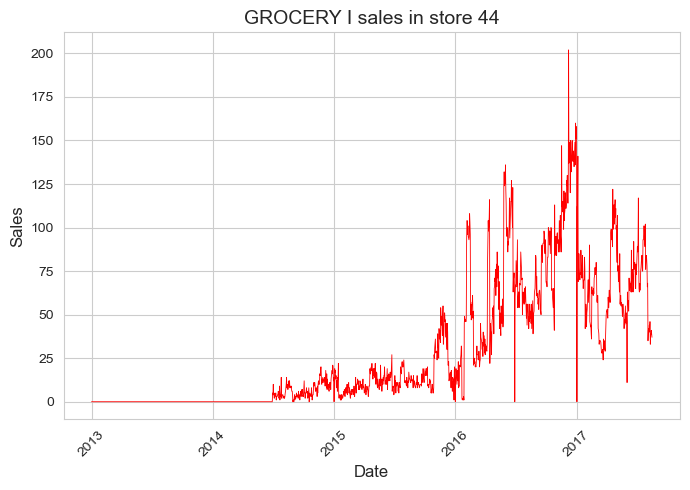

In [94]:
t_df = cross_section(df, 44, 'GROCERY I')
my_plot('GROCERY I sales in store 44', t_df['onpromotion'], 'red',0.6)

In [106]:
t_df['sum_promotions'] = t_df['onpromotion'].rolling(window=30, min_periods=1).sum()
t_df['avg_promotions'] = t_df['onpromotion'].rolling(window=30, min_periods=1).mean()

C:\Users\Alfredo.Hernandez\AppData\Local\Temp\ipykernel_10324\3695092756.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t_df['sum_promotions'] = t_df['onpromotion'].rolling(window=30, min_periods=1).sum()
C:\Users\Alfredo.Hernandez\AppData\Local\Temp\ipykernel_10324\3695092756.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t_df['avg_promotions'] = t_df['onpromotion'].rolling(window=30, min_periods=1).mean()


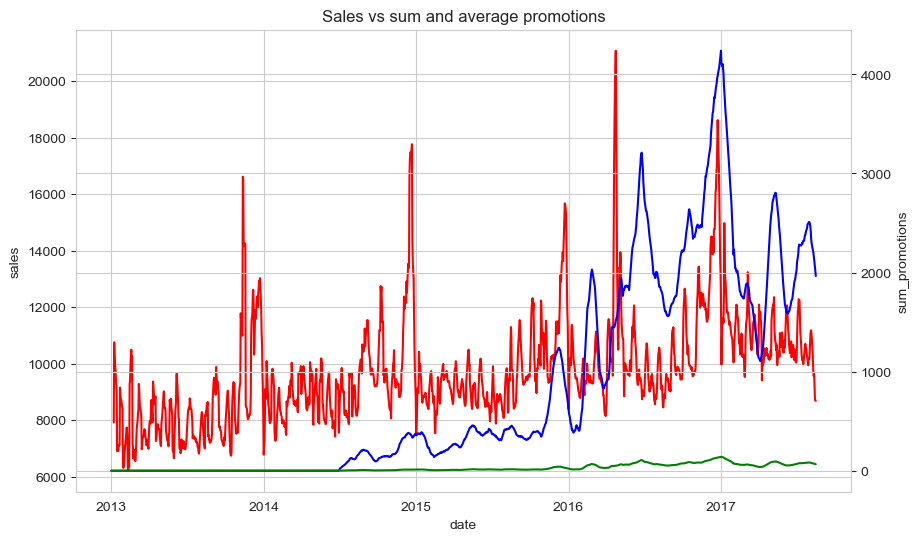

In [107]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax2 = ax1.twinx()

sns.lineplot(t_df['sales'].rolling(7).mean(), ax=ax1, color ='r')
sns.lineplot(t_df['sum_promotions'], ax=ax2, color ='b')
sns.lineplot(t_df['avg_promotions'], ax=ax2, color ='g')
plt.title('Sales vs sum and average promotions')
plt.show()

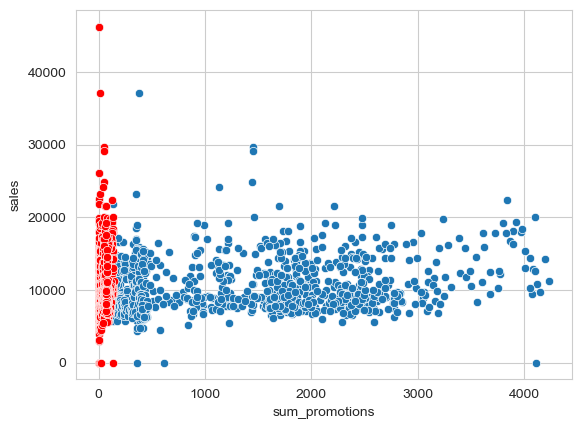

In [108]:
sns.scatterplot(t_df, x='sum_promotions', y='sales')
sns.scatterplot(t_df, x='avg_promotions', y='sales', color='r')
plt.show()

Based on this, it looks like the sum of promotions does seem to impact the sales (much more than the average). Because of this we will be keeping the sum in the df as a parameter

In [120]:
#create promo accumulation parameters
df['promotions_mtd_sum'] = df.groupby(level=['store_nbr', 'family'])['onpromotion'].transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).sum())

Now we will do a similar analysis based on transactions

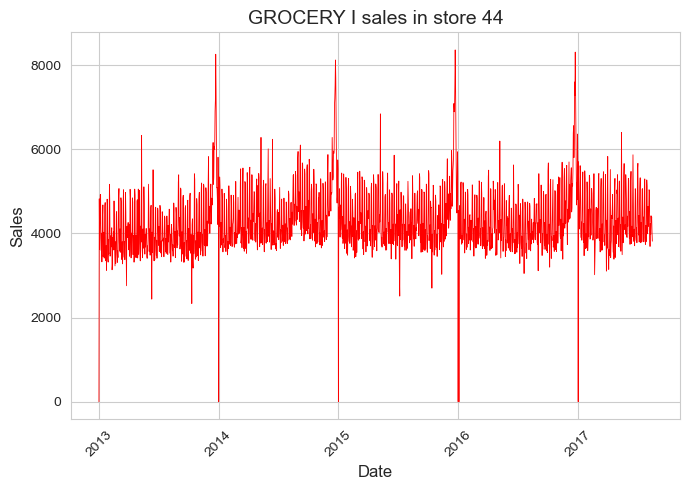

In [111]:
t_df = cross_section(df, 44, 'GROCERY I')
my_plot('GROCERY I sales in store 44', t_df['transactions'], 'red',0.6)

In [112]:
t_df['sum_transactions_wtd'] = t_df['transactions'].rolling(window=7, min_periods=1).sum()
t_df['avg_transactions_wtd'] = t_df['transactions'].rolling(window=7, min_periods=1).mean()
t_df['sum_transactions_mtd'] = t_df['transactions'].rolling(window=30, min_periods=1).sum()
t_df['avg_transactions_mtd'] = t_df['transactions'].rolling(window=30, min_periods=1).mean()

C:\Users\Alfredo.Hernandez\AppData\Local\Temp\ipykernel_10324\3193687736.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t_df['sum_transactions_wtd'] = t_df['transactions'].rolling(window=7, min_periods=1).sum()
C:\Users\Alfredo.Hernandez\AppData\Local\Temp\ipykernel_10324\3193687736.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t_df['avg_transactions_wtd'] = t_df['transactions'].rolling(window=7, min_periods=1).mean()
C:\Users\Alfredo.Hernandez\AppData\Local\Temp\ipykernel_10324\3193687736.py:3: 

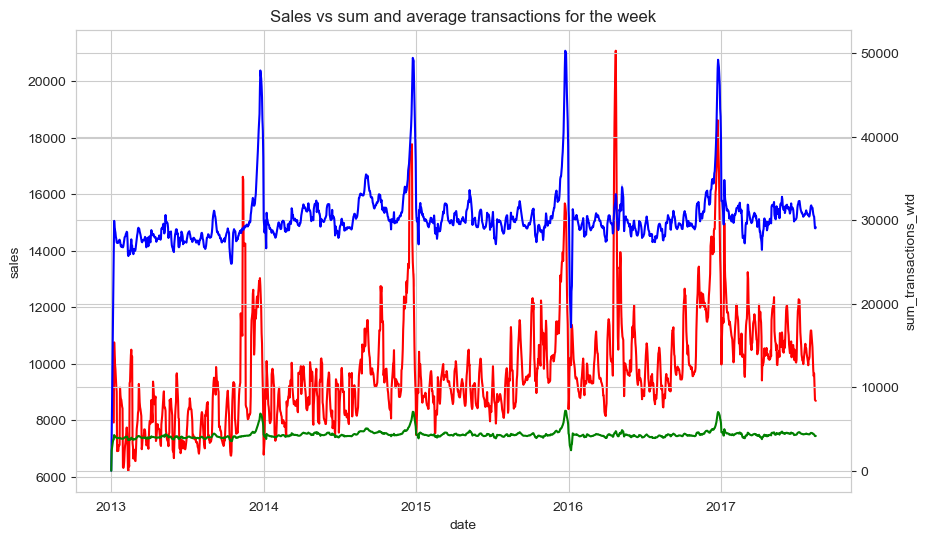

In [113]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax2 = ax1.twinx()

sns.lineplot(t_df['sales'].rolling(7).mean(), ax=ax1, color ='r')
sns.lineplot(t_df['sum_transactions_wtd'], ax=ax2, color ='b')
sns.lineplot(t_df['avg_transactions_wtd'], ax=ax2, color ='g')
plt.title('Sales vs sum and average transactions for the week')
plt.show()

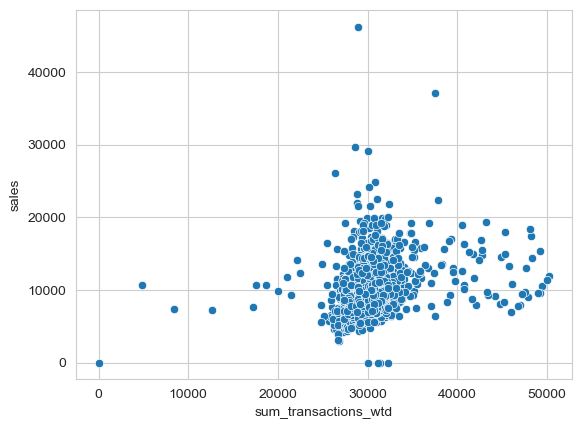

In [119]:
sns.scatterplot(t_df, x='sum_transactions_wtd', y='sales')
#sns.scatterplot(t_df, x='avg_transactions_wtd', y='sales', color='r')
plt.show()

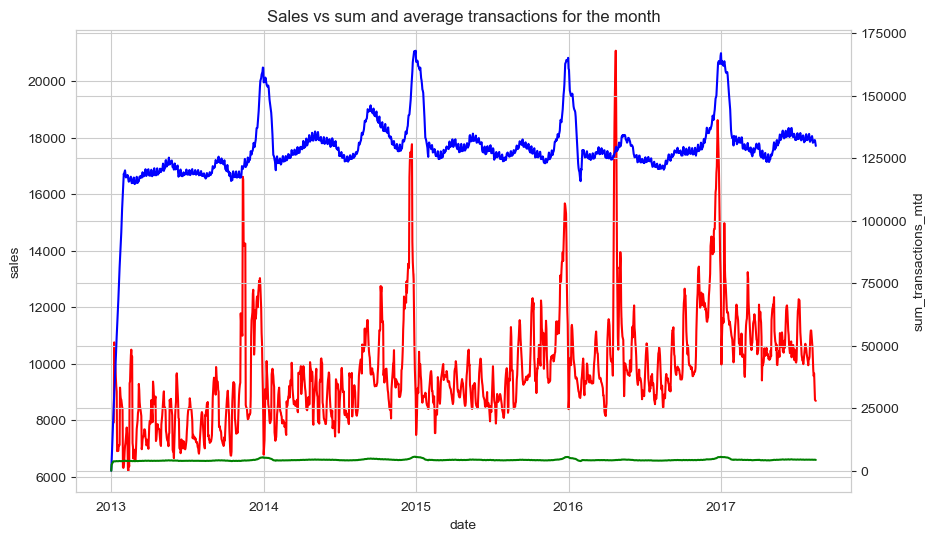

In [114]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax2 = ax1.twinx()

sns.lineplot(t_df['sales'].rolling(7).mean(), ax=ax1, color ='r')
sns.lineplot(t_df['sum_transactions_mtd'], ax=ax2, color ='b')
sns.lineplot(t_df['avg_transactions_mtd'], ax=ax2, color ='g')
plt.title('Sales vs sum and average transactions for the month')
plt.show()

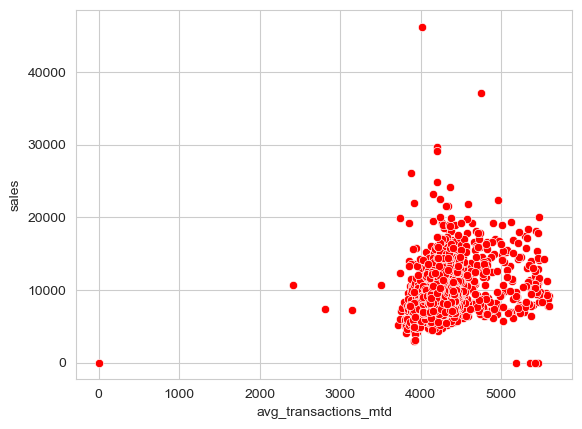

In [117]:
#sns.scatterplot(t_df, x='sum_transactions_mtd', y='sales')
sns.scatterplot(t_df, x='avg_transactions_mtd', y='sales', color='r')
plt.show()

Based on the above, we will keek the mtd average transactions only as the others dont seem to add value to the analysis

In [122]:
#create transaction accumulation parameters
df['transactions_mtd_avg'] = df.groupby(level=['store_nbr', 'family'])['transactions'].transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).mean())

Finally, we are going to do the same analysis with oil prices:

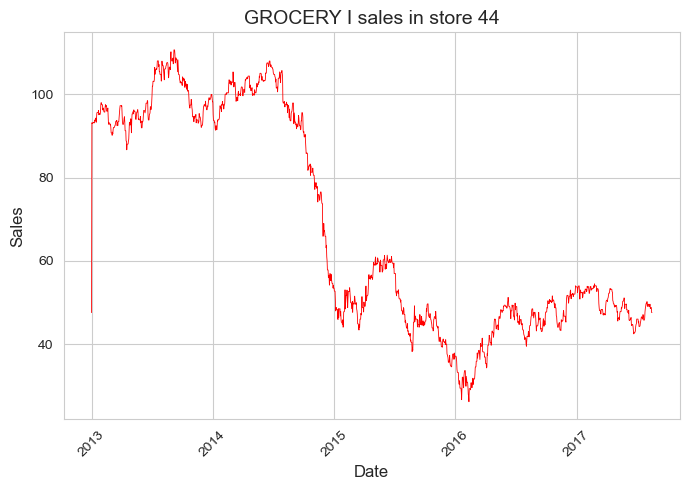

In [125]:
t_df = cross_section(df, 44, 'GROCERY I')
my_plot('GROCERY I sales in store 44', t_df['dcoilwtico'], 'red',0.6)

In [131]:
t_df['dcoilwtico'].shift(1)

date
2013-01-01      NaN
2013-01-02    47.57
2013-01-03    93.14
2013-01-04    92.97
2013-01-05    93.12
              ...  
2017-08-11    48.54
2017-08-12    48.81
2017-08-13    48.81
2017-08-14    48.81
2017-08-15    47.59
Name: dcoilwtico, Length: 1688, dtype: float64

In [135]:
t_df['oil_-1'] = t_df['dcoilwtico'].shift(1)
t_df['oil_-7'] = t_df['dcoilwtico'].shift(7)
t_df['sum_oil_wtd'] = t_df['dcoilwtico'].rolling(window=7, min_periods=1).sum()
t_df['avg_oil_wtd'] = t_df['dcoilwtico'].rolling(window=7, min_periods=1).mean()
t_df['sum_oil_mtd'] = t_df['dcoilwtico'].rolling(window=30, min_periods=1).sum()
t_df['avg_oil_mtd'] = t_df['dcoilwtico'].rolling(window=30, min_periods=1).mean()
t_df['sum_oil_qtd'] = t_df['dcoilwtico'].rolling(window=90, min_periods=1).sum()
t_df['avg_oil_qtd'] = t_df['dcoilwtico'].rolling(window=90, min_periods=1).mean()

C:\Users\Alfredo.Hernandez\AppData\Local\Temp\ipykernel_10324\1284994398.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t_df['oil_-1'] = t_df['dcoilwtico'].shift(1)
C:\Users\Alfredo.Hernandez\AppData\Local\Temp\ipykernel_10324\1284994398.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t_df['oil_-7'] = t_df['dcoilwtico'].shift(7)
C:\Users\Alfredo.Hernandez\AppData\Local\Temp\ipykernel_10324\1284994398.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
T

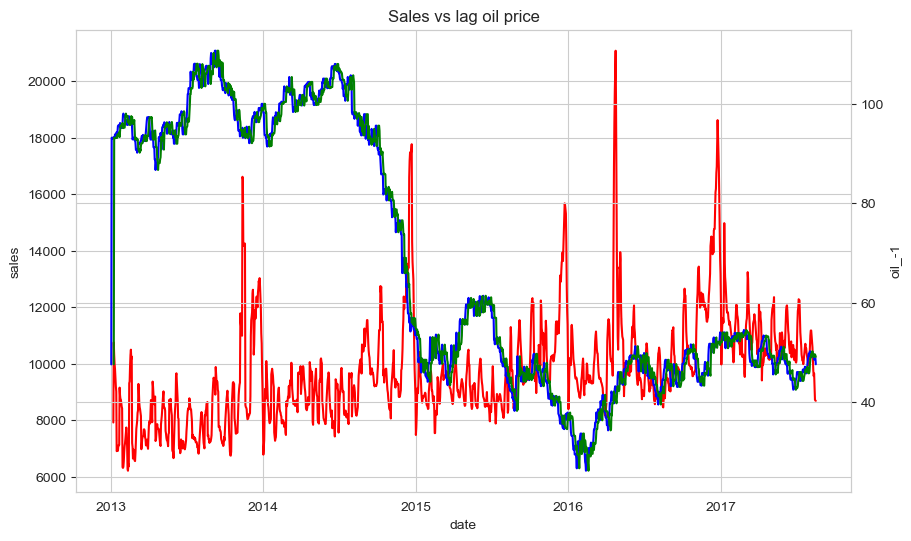

In [133]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax2 = ax1.twinx()

sns.lineplot(t_df['sales'].rolling(7).mean(), ax=ax1, color ='r')
sns.lineplot(t_df['oil_-1'], ax=ax2, color ='b')
sns.lineplot(t_df['oil_-7'], ax=ax2, color ='g')
plt.title('Sales vs lag oil price')
plt.show()

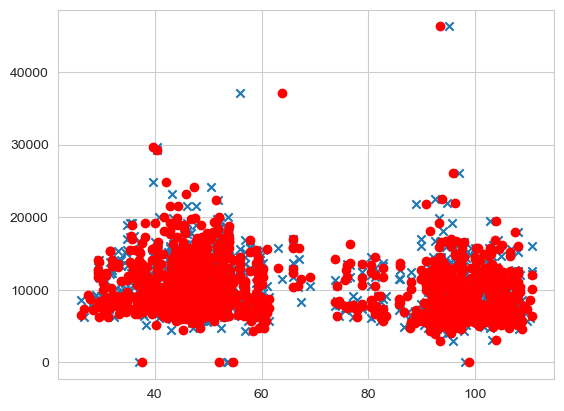

In [151]:
plt.scatter(x = t_df['oil_-1'], y=t_df['sales'], marker = 'x')
plt.scatter(x = t_df['oil_-7'], y=t_df['sales'], color='r')
plt.show()

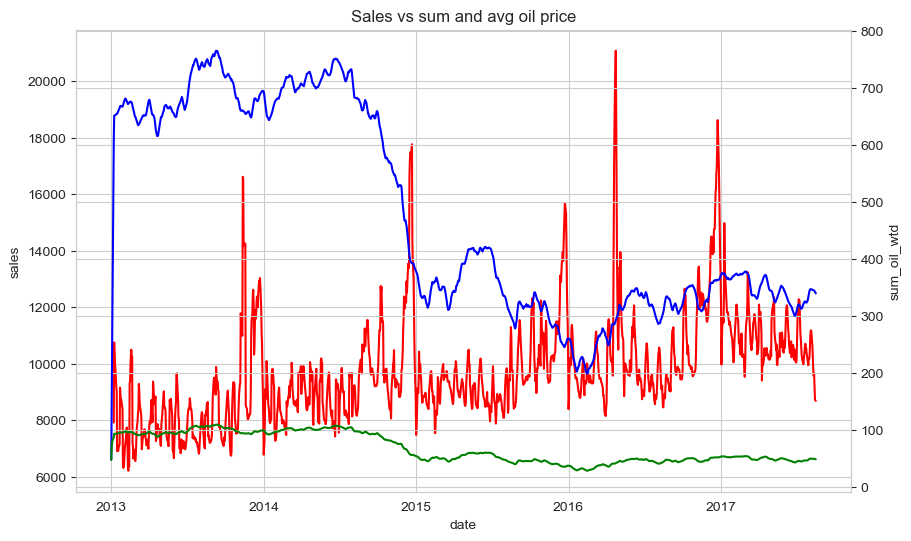

In [162]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax2 = ax1.twinx()

sns.lineplot(t_df['sales'].rolling(7).mean(), ax=ax1, color ='r')
sns.lineplot(t_df['sum_oil_wtd'], ax=ax2, color ='b')
sns.lineplot(t_df['avg_oil_wtd'], ax=ax2, color ='g')
plt.title('Sales vs sum and avg oil price')
plt.show()

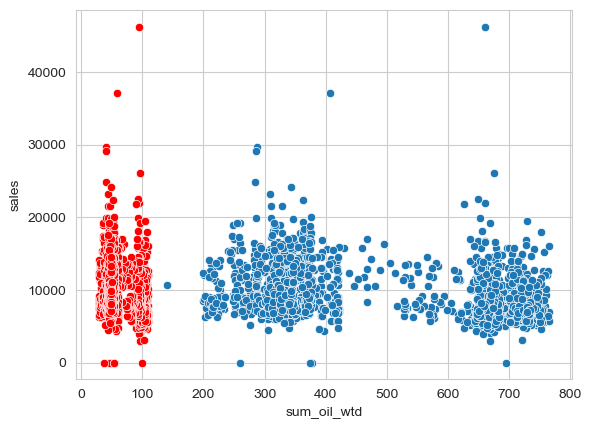

In [163]:
sns.scatterplot(t_df, x='sum_oil_wtd', y='sales')
sns.scatterplot(t_df, x='avg_oil_wtd', y='sales', color='r')
plt.show()

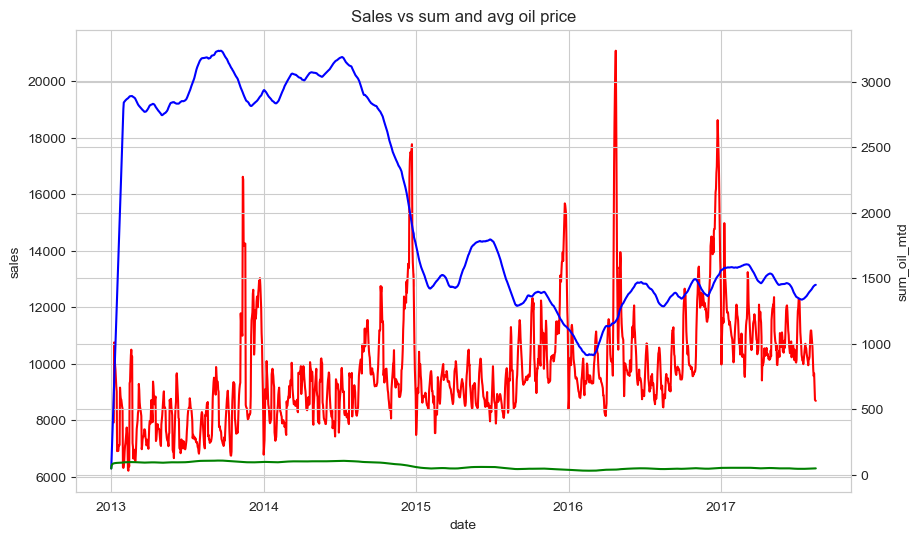

In [152]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax2 = ax1.twinx()

sns.lineplot(t_df['sales'].rolling(7).mean(), ax=ax1, color ='r')
sns.lineplot(t_df['sum_oil_mtd'], ax=ax2, color ='b')
sns.lineplot(t_df['avg_oil_mtd'], ax=ax2, color ='g')
plt.title('Sales vs sum and avg oil price')
plt.show()

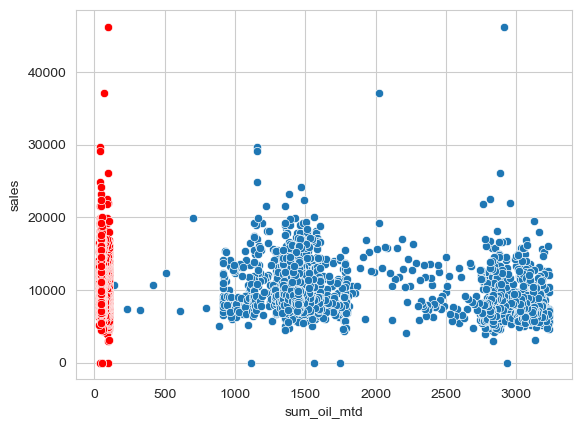

In [155]:
sns.scatterplot(t_df, x='sum_oil_mtd', y='sales')
sns.scatterplot(t_df, x='avg_oil_mtd', y='sales', color='r')
plt.show()

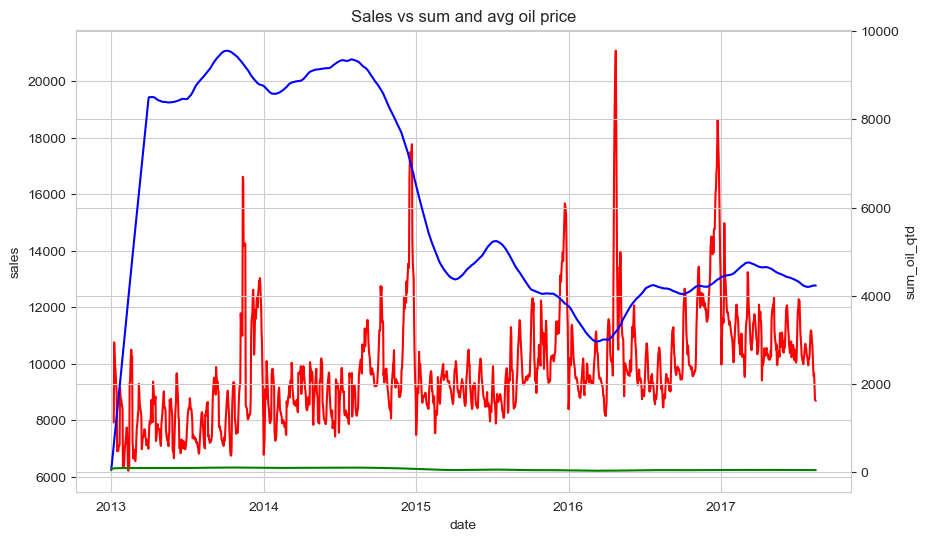

In [157]:
fig, ax1 = plt.subplots(figsize=(10, 6))

ax2 = ax1.twinx()

sns.lineplot(t_df['sales'].rolling(7).mean(), ax=ax1, color ='r')
sns.lineplot(t_df['sum_oil_qtd'], ax=ax2, color ='b')
sns.lineplot(t_df['avg_oil_qtd'], ax=ax2, color ='g')
plt.title('Sales vs sum and avg oil price')
plt.show()

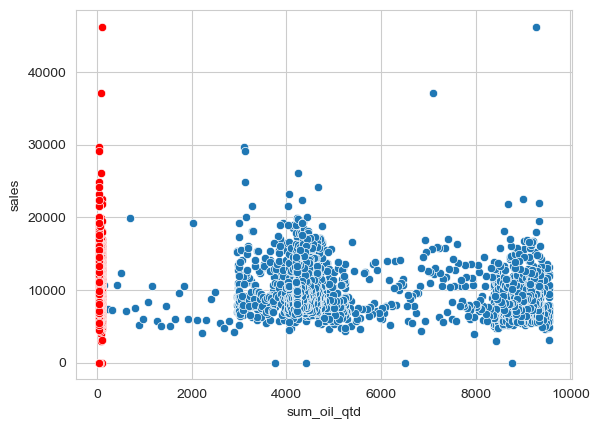

In [161]:
sns.scatterplot(t_df, x='sum_oil_qtd', y='sales')
sns.scatterplot(t_df, x='avg_oil_qtd', y='sales', color='r')
plt.show()

Considering this, we will use:

- Oil price the day before (oil_-1)
- Average oil price WTD
- Average oil price MTD
- Average oil price YTD

In [167]:
#create oil related parameters
df['oil_-1'] = df.groupby(level=['store_nbr', 'family'])['dcoilwtico'].shift(1)
df['oil_wtd_avg'] = df.groupby(level=['store_nbr', 'family'])['dcoilwtico'].transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
df['oil_mtd_avg'] = df.groupby(level=['store_nbr', 'family'])['dcoilwtico'].transform(lambda x: x.shift(1).rolling(window=30, min_periods=1).mean())
df['oil_qtd_avg'] = df.groupby(level=['store_nbr', 'family'])['dcoilwtico'].transform(lambda x: x.shift(1).rolling(window=90, min_periods=1).mean())

Now we will create the deate parameters:
- Day of  the month
- Month of the year
- year
- day of the week
- week of the year
- days since beginning

In [185]:
df['day'] = df.index.get_level_values('date').day
df['month'] = df.index.get_level_values('date').month
df['year'] = df.index.get_level_values('date').year

In [191]:
df['day_of_week'] = df.index.get_level_values('date').dayofweek

In [198]:
df['week_num'] = df.index.get_level_values('date').isocalendar().week.values

In [199]:
df.head()

sales  onpromotion  transactions   city  \
store_nbr family     date                                                  
1         AUTOMOTIVE 2013-01-01    0.0            0           0.0  Quito   
                     2013-01-02    2.0            0        2111.0  Quito   
                     2013-01-03    3.0            0        1833.0  Quito   
                     2013-01-04    3.0            0        1863.0  Quito   
                     2013-01-05    5.0            0        1509.0  Quito   

                                     state type_store  cluster type_holiday  \
store_nbr family     date                                                     
1         AUTOMOTIVE 2013-01-01  Pichincha          D       13            0   
                     2013-01-02  Pichincha          D       13            0   
                     2013-01-03  Pichincha          D       13            0   
                     2013-01-04  Pichincha          D       13            0   
                     2013-01-05  Pichincha          D       13            0   

                                locale_holiday transferred_holiday  ...  \
store_nbr family     date                                           ...   
1         AUTOMOTIVE 2013-01-01              0                   0  ...   
                     2013-01-02              0                   0  ...   
                     2013-01-03              0                   0  ...   
                     2013-01-04              0                   0  ...   
                     2013-01-05              0                   0  ...   

                                transactions_mtd_avg oil_-1 oil_wtd_avg  \
store_nbr family     date                                                 
1         AUTOMOTIVE 2013-01-01                  NaN    NaN         NaN   
                     2013-01-02             0.000000  93.14   93.140000   
                     2013-01-03          1055.500000  93.14   93.140000   
                     2013-01-04          1314.666667  92.97   93.083333   
                     2013-01-05          1451.750000  93.12   93.092500   

                                 oil_mtd_avg  oil_qtd_avg  day  month  year  \
store_nbr family     date                                                     
1         AUTOMOTIVE 2013-01-01          NaN          NaN    1      1  2013   
                     2013-01-02    93.140000    93.140000    2      1  2013   
                     2013-01-03    93.140000    93.140000    3      1  2013   
                     2013-01-04    93.083333    93.083333    4      1  2013   
                     2013-01-05    93.092500    93.092500    5      1  2013   

                                 day_of_week  week_num  
store_nbr family     date                               
1         AUTOMOTIVE 2013-01-01            1         1  
                     2013-01-02            2         1  
                     2013-01-03            3         1  
                     2013-01-04            4         1  
                     2013-01-05            5         1  

[5 rows x 29 columns]

In [204]:
df['x_days'] = (df.index.get_level_values('date') - df.index.get_level_values('date')[0]).days

Since we have all our EDA complete, we will save the model and start the modeling stage

In [205]:
#save for lateruse
df.to_pickle('cleaned_store_sales.pkl')